In [1]:
from google.colab import drive

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

In [13]:
os.chdir('/content/drive/MyDrive/cv_project')

In [14]:
import pandas as pd
import numpy as np

In [15]:
df = pd.read_csv('imbalanced_data.csv')

In [16]:
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [17]:
df['tweet']

,tweet
0,@user when a father is dysfunctional and is s...
1,@user @user thanks for #lyft credit i can't us...
2,bihday your majesty
3,#model i love u take with u all the time in ...
4,factsguide: society now #motivation
...,...
31957,ate @user isz that youuu?ðððððð...
31958,to see nina turner on the airwaves trying to...
31959,listening to sad songs on a monday morning otw...
31960,"@user #sikh #temple vandalised in in #calgary,..."


In [18]:
import seaborn as sns

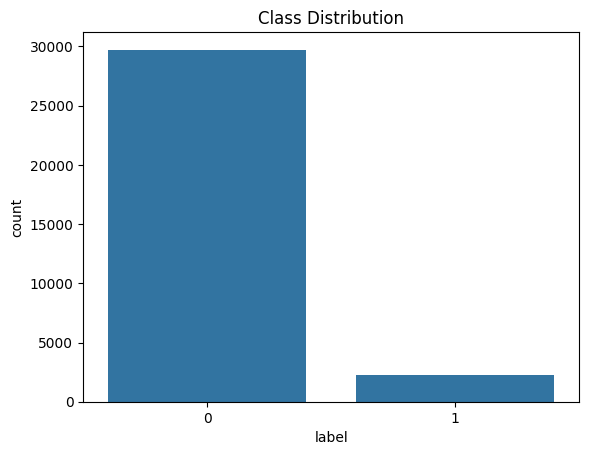

label
0    0.929854
1    0.070146
Name: proportion, dtype: float64


In [19]:
import matplotlib.pyplot as plt
sns.countplot(x=df['label'])
plt.title("Class Distribution")
plt.show()

print(df['label'].value_counts(normalize=True))

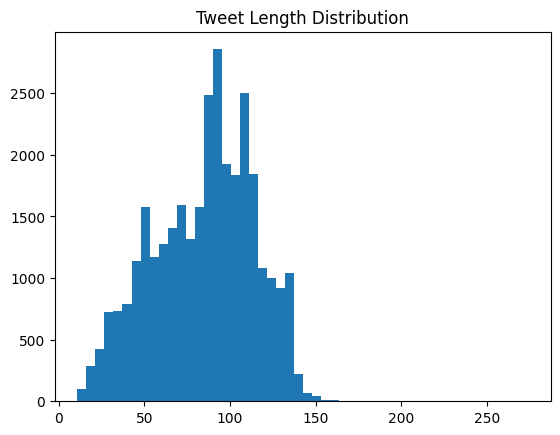

In [20]:
#Tweet Length Analysis
df['length'] = df['tweet'].apply(len)

plt.hist(df['length'], bins=50)
plt.title("Tweet Length Distribution")
plt.show()

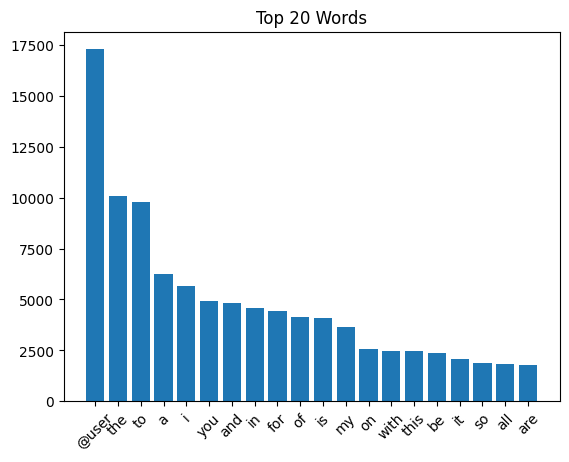

In [21]:
#Most Common Words
from collections import Counter

all_words = " ".join(df['tweet']).split()
common_words = Counter(all_words).most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words")
plt.show()

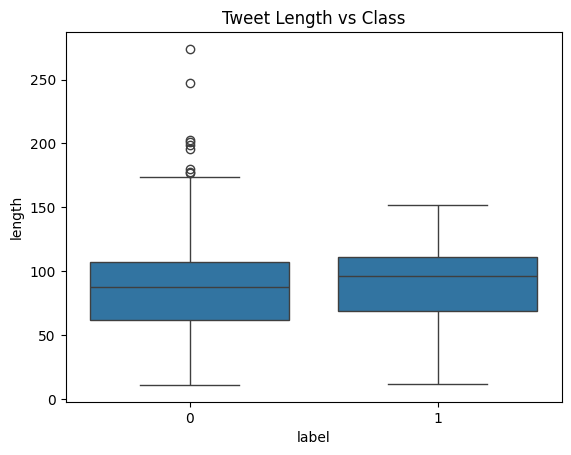

In [22]:
sns.boxplot(x='label', y='length', data=df)
plt.title("Tweet Length vs Class")
plt.show()

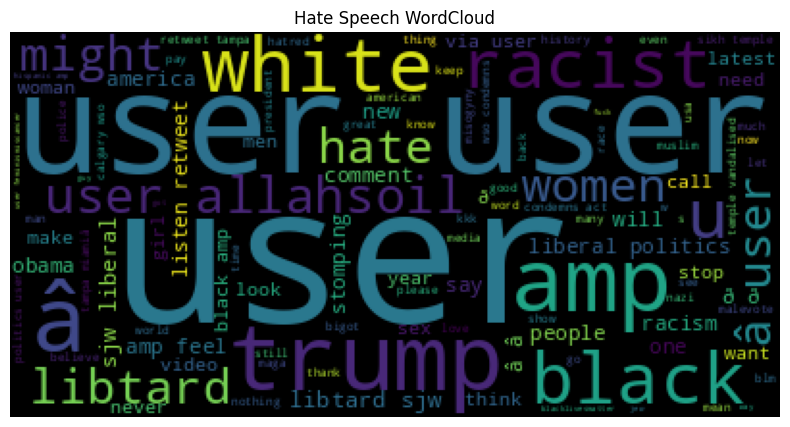

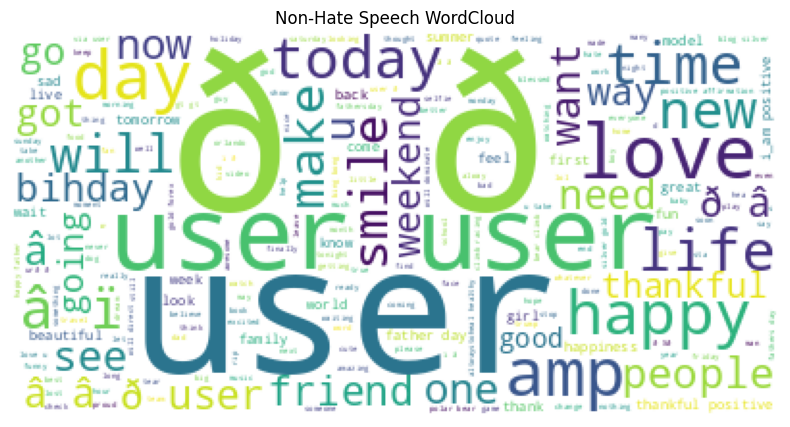

In [23]:
#WORD CLOUD (HATE vs NON-HATE)
from wordcloud import WordCloud

hate_words = " ".join(df[df['label'] == 1]['tweet'])
non_hate_words = " ".join(df[df['label'] == 0]['tweet'])

# Hate Speech
plt.figure(figsize=(10,5))
wc = WordCloud(background_color='black').generate(hate_words)
plt.imshow(wc)
plt.axis('off')
plt.title("Hate Speech WordCloud")
plt.show()

# Non-Hate Speech
plt.figure(figsize=(10,5))
wc = WordCloud(background_color='white').generate(non_hate_words)
plt.imshow(wc)
plt.axis('off')
plt.title("Non-Hate Speech WordCloud")
plt.show()

In [24]:
from nltk.corpus import stopwords
import re
import string
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [25]:
stemmer = nltk.SnowballStemmer("english")
stopword = set(stopwords.words('english'))

In [26]:
def data_cleaning(words):
    words = words.lower()
    words = re.sub(r'@\w+', '', words)  # remove mentions
    words = re.sub(r'http\S+', '', words)  # remove URLs
    words = re.sub(r'[^a-z\s]', '', words)  # remove special chars & numbers
    words = re.sub(r'\s+', ' ', words).strip()

    words = [word for word in words.split() if word not in stopword]
    words=" ".join(words)
    words = [stemmer.stem(word) for word in words.split()]
    words=" ".join(words)

    return words

In [27]:
df.head()

,id,label,tweet,length
0,1,0,@user when a father is dysfunctional and is s...,102
1,2,0,@user @user thanks for #lyft credit i can't us...,122
2,3,0,bihday your majesty,21
3,4,0,#model i love u take with u all the time in ...,86
4,5,0,factsguide: society now #motivation,39


In [28]:
df['tweet']=df['tweet'].apply(data_cleaning)

In [29]:
df.head()

,id,label,tweet,length
0,1,0,father dysfunct selfish drag kid dysfunct run,102
1,2,0,thank lyft credit cant use caus dont offer whe...,122
2,3,0,bihday majesti,21
3,4,0,model love u take u time ur,86
4,5,0,factsguid societi motiv,39


In [30]:
df.iloc[0]['tweet']

'father dysfunct selfish drag kid dysfunct run'

In [31]:
X = df['tweet']
y = df['label']

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

print(len(X_train),len(X_test))
print(len(y_train),len(y_test))

25569 6393
25569 6393


In [34]:
from keras import Sequential
from keras.layers import Dense,SimpleRNN, Embedding, Flatten

In [35]:
all_words = [word for sentence in df['tweet'] for word in sentence.split()]

unique_words = set(all_words)
vocab_size = len(unique_words)

print('vocabulary size',vocab_size)

vocabulary size 33429


In [37]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
max_words = 50000
max_len = 300

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [38]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense
from tensorflow.keras.layers import Attention, GlobalAveragePooling1D

# Input
inputs = Input(shape=(max_len,))

# Embedding
embedding = Embedding(input_dim=max_words, output_dim=100)(inputs)

# RNN (IMPORTANT: return_sequences=True)
rnn_out = SimpleRNN(100, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(embedding)

# Attention Layer
attention_out = Attention()([rnn_out, rnn_out])

# Pooling (convert sequence → single vector)
context_vector = GlobalAveragePooling1D()(attention_out)

# Output
outputs = Dense(1, activation='sigmoid')(context_vector)

# Model
model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 100)  │  5,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 300, 100)  │     20,100 │ embedding[0][0]   │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 300, 100)  │          0 │ simple_rnn[0][0], │
│ (Attention)         │                   │            │ simple_rnn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │        101 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,020,201 (19.15 MB)

 Trainable params: 5,020,201 (19.15 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
from keras.optimizers import RMSprop

In [40]:
model.compile(loss='binary_crossentropy',optimizer=RMSprop(),metrics=['accuracy'])

In [41]:
history = model.fit(
    X_train_pad, y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 180s 890ms/step - accuracy: 0.9284 - loss: 0.2628 - val_accuracy: 0.9287 - val_loss: 0.2667
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 192s 842ms/step - accuracy: 0.9301 - loss: 0.2562 - val_accuracy: 0.9287 - val_loss: 0.2620
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 165s 826ms/step - accuracy: 0.9301 - loss: 0.2550 - val_accuracy: 0.9287 - val_loss: 0.2821
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 211s 872ms/step - accuracy: 0.9301 - loss: 0.2553 - val_accuracy: 0.9287 - val_loss: 0.2571
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 162s 813ms/step - accuracy: 0.9301 - loss: 0.2543 - val_accuracy: 0.9287 - val_loss: 0.2586
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 170s 852ms/step - accuracy: 0.9301 - loss: 0.2548 - val_accuracy: 0.9287 - val_loss: 0.2575
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 163s 813ms/step - accuracy: 0.9301 - loss: 0.2542 - val_accuracy: 0.9287 - val_loss: 0.2610
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 163s 814ms/step - accuracy: 0.9301 -

In [42]:
loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - accuracy: 0.9287 - loss: 0.2571
Test Accuracy: 0.9286719560623169


In [43]:
rnn_prediction = model.predict(X_test_pad)

200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step


In [44]:
rnn_prediction

array([[0.07067686],
       [0.07067643],
       [0.07067553],
       ...,
       [0.0706746 ],
       [0.07067446],
       [0.07067273]], dtype=float32)

In [45]:
res = []
for prediction in rnn_prediction:
    if prediction[0] < 0.5:
        res.append(0)
    else:
        res.append(1)

In [46]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,res))

[[5937    0]
 [ 456    0]]


In [47]:
import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [48]:
import keras

In [49]:
model.save("model.h5")


In [50]:
load_model=keras.models.load_model("model.h5")

In [51]:
with open('tokenizer.pickle', 'rb') as handle:
    load_tokenizer = pickle.load(handle)